# Active Inference for Grocery Inventory Management

## Goal
Binary daily decision per SKU: **order new stock** vs. **don't order**.
Minimize stock levels while avoiding stock-outs (homeostatic framing).

## Architecture
- **Generative process**: parametric inventory simulator (not neural net)
  — the dataset snapshot provides the parameters for each SKU's dynamics
- **Preference model**: homeostatic C matrix with precision-weighted targets
- **Active inference agent**: minimizes expected free energy (pragmatic + epistemic)
- **Baseline**: dataset's built-in reorder point (classical (s,Q) policy)

## Dataset
Kaggle E-Grocery Inventory Management (1000 SKUs, cross-sectional snapshot).
Each row parameterizes one SKU: demand rate, lead time, supplier reliability, etc.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from tqdm.auto import tqdm

sys.path.insert(0, str(Path.cwd() / 'src'))

from applied_active_inference.grocery import (
    parse_european_number, extract_sku_params, make_initial_state,
    GrocerySimulator, GroceryPreferences, GaussianPreferences,
    ObservationModel, BeliefState, GroceryAIAgent,
    ReorderPointAgent, run_simulation, INV, ON_ORDER, DAYS_UNTIL,
)

DATA_PATH = Path.home() / '.cache/kagglehub/datasets/mustofaahmad/inventory-management-grocery-industry/versions/1/Inventory Management E-Grocery - InventoryData.csv'
print(f'Data: {DATA_PATH}')
print(f'Exists: {DATA_PATH.exists()}')

Data: C:\Users\mahau\.cache\kagglehub\datasets\mustofaahmad\inventory-management-grocery-industry\versions\1\Inventory Management E-Grocery - InventoryData.csv
Exists: True


## 1. Data Loading & Exploration

In [2]:
# Load and parse European number format
df = pd.read_csv(DATA_PATH)

# Columns that need European number parsing (comma = decimal, dot = thousands)
euro_cols = [
    'Avg_Daily_Sales', 'Days_of_Inventory', 'Unit_Cost_USD',
    'Last_Purchase_Price_USD', 'Total_Inventory_Value_USD',
    'SKU_Churn_Rate', 'Order_Frequency_per_month',
    'Supplier_OnTime_Pct', 'Audit_Variance_Pct',
    'Demand_Forecast_Accuracy_Pct',
]
for col in euro_cols:
    df[col] = df[col].apply(parse_european_number)

# Forecast_Next_30d uses dots as thousands separators (1.377 = 1377)
df['Forecast_Next_30d'] = df['Forecast_Next_30d'].apply(
    lambda x: float(str(x).replace('.', '')) if isinstance(x, str) else float(x)
)

# Derived columns
df['ATP'] = df['Quantity_On_Hand'] - df['Quantity_Reserved'] - df['Quantity_Committed']
df['Demand_Std'] = df['Avg_Daily_Sales'] * (1.0 - df['Demand_Forecast_Accuracy_Pct'] / 100.0)

print(f'Shape: {df.shape}')
print(f'Categories: {df["Category"].nunique()}')
print(f'Warehouses: {df["Warehouse_ID"].nunique()}')
print(f'ABC classes: {df["ABC_Class"].value_counts().to_dict()}')
df.head(3)

Shape: (1000, 39)
Categories: 10
Warehouses: 5
ABC classes: {'C': 500, 'B': 300, 'A': 200}


,SKU_ID,SKU_Name,Category,ABC_Class,Supplier_ID,Supplier_Name,Warehouse_ID,Warehouse_Location,Batch_ID,Received_Date,...,Supplier_OnTime_Pct,FIFO_FEFO,Inventory_Status,Count_Variance,Audit_Date,Audit_Variance_Pct,Demand_Forecast_Accuracy_Pct,Notes,ATP,Demand_Std
0,SKU0001,Pantry Product 13,Pantry,A,S005,PT Agro Raya,WHBDG,Bandung - Rancaekek,BATCH2679,2025-07-14,...,70.68,FIFO,In Stock,0,2025-06-26,-7.14,95.67,NaN,223,1.237081
1,SKU0002,Fresh Product 112,Fresh Produce,C,S004,PT Nusantara Supplier,WHDPS,Denpasar - Tabanan,BATCH4257,2025-04-08,...,84.61,FEFO,Low Stock,4,2025-08-12,2.15,86.00,NaN,250,4.898600
2,SKU0003,Meat Product 446,Meat,B,S001,PT Segar Makmur,WHBDG,Bandung - Rancaekek,BATCH6574,2025-03-15,...,85.36,FIFO,Expiring Soon,-5,2025-08-13,6.85,87.64,NaN,395,4.517580


In [3]:
# Key statistics for the active inference model
key_cols = [
    'ATP', 'Avg_Daily_Sales', 'Reorder_Point', 'Safety_Stock',
    'Lead_Time_Days', 'Supplier_OnTime_Pct', 'Demand_Forecast_Accuracy_Pct',
    'Days_of_Inventory', 'Unit_Cost_USD',
]
print('=== Key Variable Statistics ===')
print(df[key_cols].describe().round(2).to_string())

print(f'\nNegative ATP: {(df["ATP"] < 0).sum()} SKUs')
print(f'ATP < Safety Stock: {(df["ATP"] < df["Safety_Stock"]).sum()} / {len(df)} SKUs')
print(f'\nInventory Status:\n{df["Inventory_Status"].value_counts().to_string()}')

=== Key Variable Statistics ===
           ATP  Avg_Daily_Sales  Reorder_Point  Safety_Stock  Lead_Time_Days  Supplier_OnTime_Pct  Demand_Forecast_Accuracy_Pct  Days_of_Inventory  Unit_Cost_USD
count  1000.00          1000.00        1000.00       1000.00         1000.00              1000.00                       1000.00            1000.00        1000.00
mean    142.52            26.58         152.80         58.47            4.03                84.67                         78.97               9.99           6.39
std     168.26            21.25         163.06         66.05            2.98                 8.46                         11.07               3.80           5.39
min    -672.00             1.01           1.00          2.00            1.00                70.03                         60.01               0.00           0.29
25%      36.00            10.73          46.00         19.00            2.00                77.56                         70.06               7.42           2

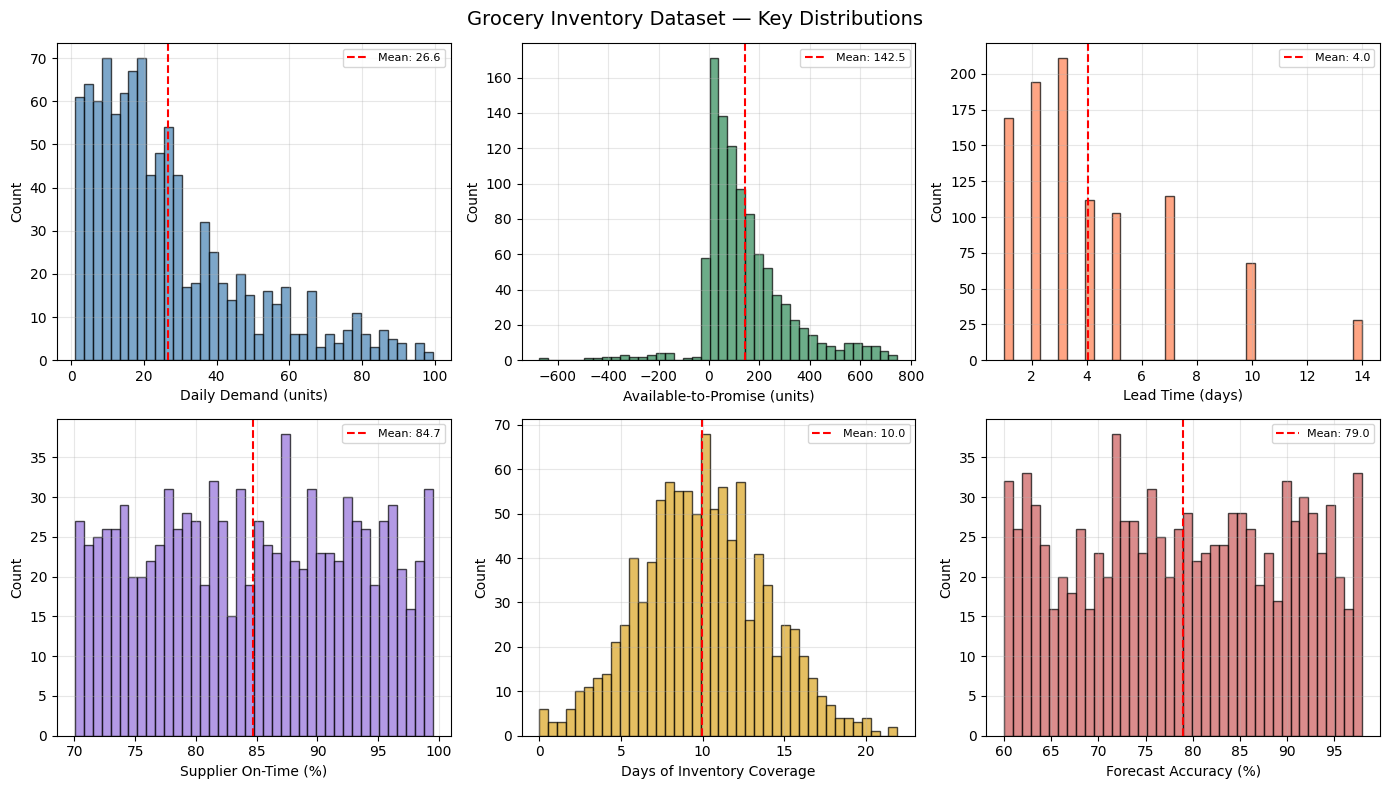

In [4]:
# Visualize distributions of key parameters
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Grocery Inventory Dataset — Key Distributions', fontsize=14)

plot_info = [
    ('Avg_Daily_Sales', 'Daily Demand (units)', 'steelblue'),
    ('ATP', 'Available-to-Promise (units)', 'seagreen'),
    ('Lead_Time_Days', 'Lead Time (days)', 'coral'),
    ('Supplier_OnTime_Pct', 'Supplier On-Time (%)', 'mediumpurple'),
    ('Days_of_Inventory', 'Days of Inventory Coverage', 'goldenrod'),
    ('Demand_Forecast_Accuracy_Pct', 'Forecast Accuracy (%)', 'indianred'),
]

for ax, (col, label, color) in zip(axes.flat, plot_info):
    ax.hist(df[col], bins=40, edgecolor='black', alpha=0.7, color=color)
    ax.axvline(df[col].mean(), color='red', ls='--', lw=1.5, label=f'Mean: {df[col].mean():.1f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

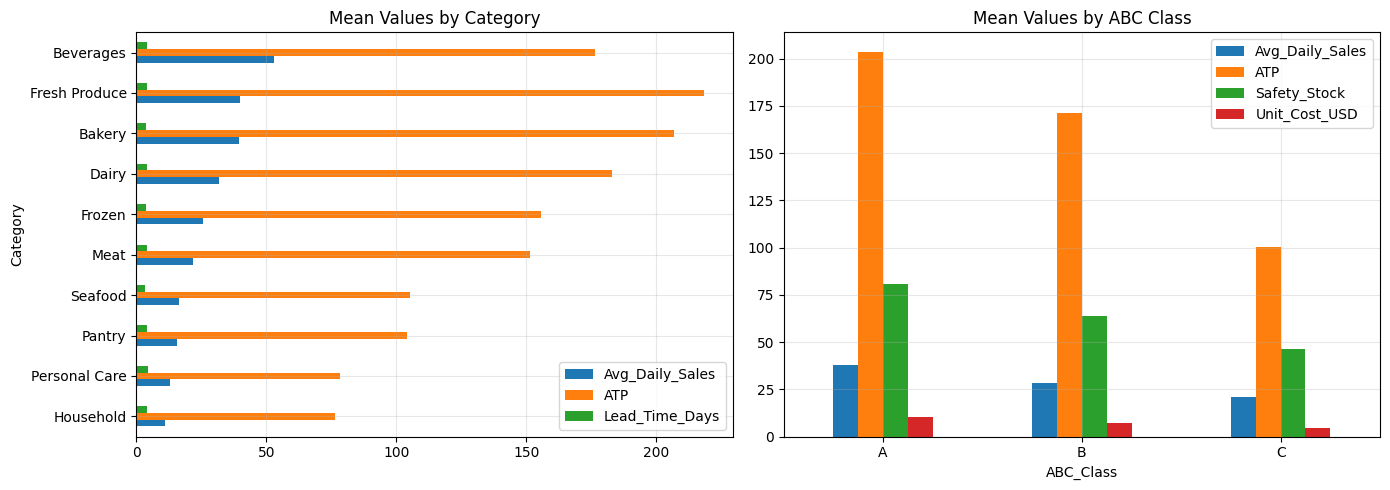

In [5]:
# Breakdown by category and ABC class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By category
cat_stats = df.groupby('Category')[['Avg_Daily_Sales', 'ATP', 'Lead_Time_Days']].mean()
cat_stats.sort_values('Avg_Daily_Sales', ascending=True).plot.barh(ax=axes[0])
axes[0].set_title('Mean Values by Category')
axes[0].grid(True, alpha=0.3)

# By ABC class
abc_stats = df.groupby('ABC_Class')[['Avg_Daily_Sales', 'ATP', 'Safety_Stock', 'Unit_Cost_USD']].mean()
abc_stats.plot.bar(ax=axes[1], rot=0)
axes[1].set_title('Mean Values by ABC Class')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Single-SKU Sanity Check

Before running the full comparison, validate the simulator on one SKU.
Under a pure **hold** policy (never order), inventory should deplete
at roughly `Avg_Daily_Sales` per day and hit zero around `ATP / Avg_Daily_Sales` days.

SKU: SKU0001 (Pantry, A-class)
  Avg Daily Sales: 28.6
  ATP: 223
  Expected depletion (no reorder): 7.8 days
  Lead Time: 1 days
  Reorder Point: 51
  Safety Stock: 22
  Supplier On-Time: 70.7%
  Demand Std: 1.43


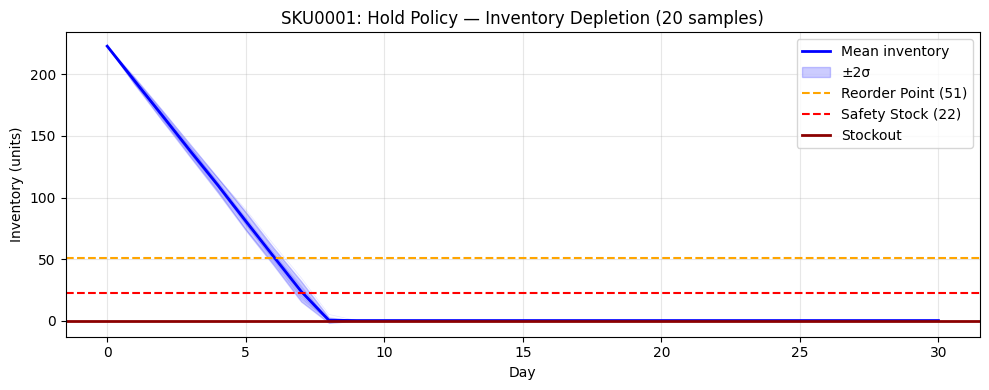

Mean days to stockout (hold): 8.1 (expected: 7.8)


In [6]:
# Pick SKU0001 for sanity check
sku_row = df.iloc[0]
params = extract_sku_params(sku_row)
print(f'SKU: {params.sku_id} ({params.category}, {params.abc_class}-class)')
print(f'  Avg Daily Sales: {params.avg_daily_sales:.1f}')
print(f'  ATP: {params.atp:.0f}')
print(f'  Expected depletion (no reorder): {params.atp / params.avg_daily_sales:.1f} days')
print(f'  Lead Time: {params.lead_time_days} days')
print(f'  Reorder Point: {params.reorder_point:.0f}')
print(f'  Safety Stock: {params.safety_stock}')
print(f'  Supplier On-Time: {params.supplier_on_time:.1%}')
print(f'  Demand Std: {params.demand_std:.2f}')

sim = GrocerySimulator(params)
s0 = make_initial_state(params)

# Hold policy agent (never orders)
class HoldAgent:
    def select_action(self, state):
        return 0, [0.0, 0.0]

# Run 20 stochastic hold simulations
hold_trajs = []
for seed in range(20):
    result = run_simulation(HoldAgent(), sim, s0, horizon=30, seed=seed)
    hold_trajs.append(result['states'][:, INV])

hold_trajs = np.array(hold_trajs)
mean_traj = hold_trajs.mean(axis=0)
std_traj = hold_trajs.std(axis=0)

plt.figure(figsize=(10, 4))
days = np.arange(len(mean_traj))
plt.plot(days, mean_traj, 'b-', lw=2, label='Mean inventory')
plt.fill_between(days, mean_traj - 2*std_traj, mean_traj + 2*std_traj,
                 alpha=0.2, color='blue', label='±2σ')
for t in hold_trajs:
    plt.plot(days, t, 'b-', alpha=0.1, lw=0.5)
plt.axhline(params.reorder_point, color='orange', ls='--', label=f'Reorder Point ({params.reorder_point:.0f})')
plt.axhline(params.safety_stock, color='red', ls='--', label=f'Safety Stock ({params.safety_stock})')
plt.axhline(0, color='darkred', ls='-', lw=2, label='Stockout')
plt.xlabel('Day'); plt.ylabel('Inventory (units)')
plt.title(f'{params.sku_id}: Hold Policy — Inventory Depletion (20 samples)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

zero_days = [(t <= 0).argmax() if (t <= 0).any() else 30 for t in hold_trajs]
print(f'Mean days to stockout (hold): {np.mean(zero_days):.1f} (expected: {params.atp/params.avg_daily_sales:.1f})')

## 3. Single-SKU Comparison: AI Agent vs Reorder Point Baseline

Run both agents on the same SKU with the same random seeds.
The baseline uses the dataset's built-in `Reorder_Point` threshold.

In [7]:
# Set up agents for SKU0001
prefs = GaussianPreferences(params)
obs_model = ObservationModel(params, obs_rng=sim.obs_rng)
print(f'Preference target inventory (S): {prefs.target_inventory:.1f} units '
      f'({prefs.target_inventory / params.avg_daily_sales:.1f} days of supply)')

ai_agent = GroceryAIAgent(sim, prefs, obs_model, n_rollouts=30, gamma=4.0, use_analytical=True)
baseline_agent = ReorderPointAgent(params)

HORIZON = 90  # 3 months
SEED = 42

print('Running baseline (reorder point)...')
bl_result = run_simulation(baseline_agent, sim, s0, horizon=HORIZON, seed=SEED)
print(f'  Fill rate: {bl_result["fill_rate"]:.1%}, Orders: {bl_result["total_orders"]}, '
      f'Avg inv: {bl_result["avg_inventory"]:.0f}')

print('Running active inference agent (proper VFE + EFE)...')
ai_result = run_simulation(ai_agent, sim, s0, horizon=HORIZON, seed=SEED, obs_model=obs_model)
print(f'  Fill rate: {ai_result["fill_rate"]:.1%}, Orders: {ai_result["total_orders"]}, '
      f'Avg inv: {ai_result["avg_inventory"]:.0f}')
if 'avg_vfe' in ai_result:
    print(f'  Avg VFE: {ai_result["avg_vfe"]:.2f}')

Preference target inventory (S): 60.5 units (2.1 days of supply)
Running baseline (reorder point)...
  Fill rate: 76.7%, Orders: 83, Avg inv: 28
Running active inference agent (proper VFE + EFE)...
  Fill rate: 64.4%, Orders: 79, Avg inv: 24
  Avg VFE: 53.43


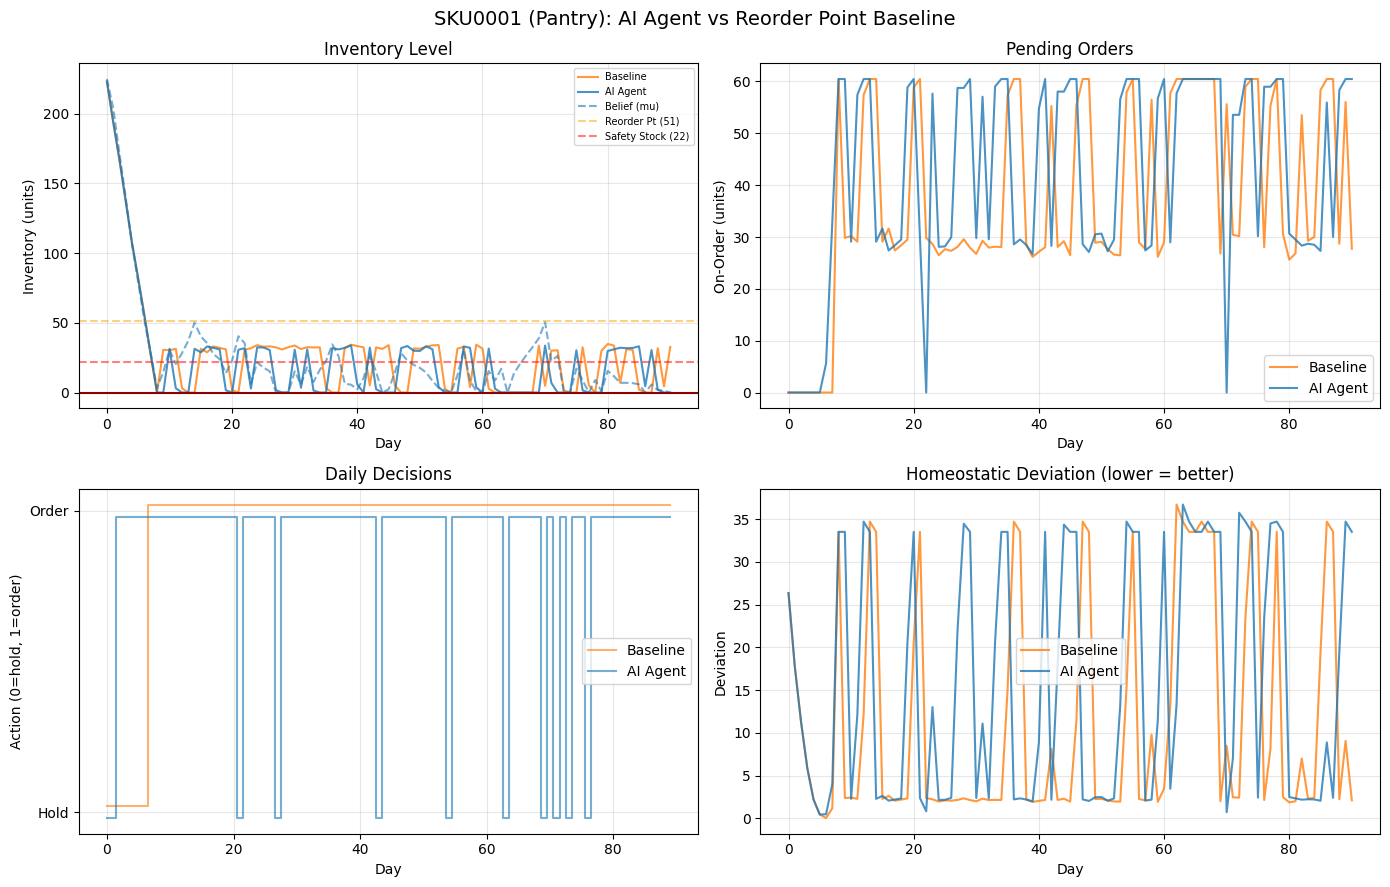


Metric                           Baseline   AI Agent
Fill rate                           76.7%      64.4%
Stockout days                          21         32
Total orders                           83         79
Avg inventory                          28         24
Min inventory                           0          0
Mean deviation                     11.737     16.047
Lost sales (units)                    547        850


In [8]:
# Detailed comparison plots for single SKU
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f'{params.sku_id} ({params.category}): AI Agent vs Reorder Point Baseline', fontsize=14)
days = np.arange(HORIZON + 1)

# 1. Inventory trajectory
ax = axes[0, 0]
ax.plot(days, bl_result['states'][:, INV], label='Baseline', alpha=0.8, color='tab:orange')
ax.plot(days, ai_result['states'][:, INV], label='AI Agent', alpha=0.8, color='tab:blue')
if 'belief_trace' in ai_result:
    belief_inv = np.array(ai_result['belief_trace'])[:, INV]
    ax.plot(np.arange(len(belief_inv)), belief_inv, label='Belief (mu)', alpha=0.6, color='tab:blue', ls='--')
ax.axhline(params.reorder_point, color='orange', ls='--', alpha=0.5, label=f'Reorder Pt ({params.reorder_point:.0f})')
ax.axhline(params.safety_stock, color='red', ls='--', alpha=0.5, label=f'Safety Stock ({params.safety_stock})')
ax.axhline(0, color='darkred', ls='-', lw=1.5)
ax.set_xlabel('Day'); ax.set_ylabel('Inventory (units)')
ax.set_title('Inventory Level'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# 2. On-order quantity
ax = axes[0, 1]
ax.plot(days, bl_result['states'][:, ON_ORDER], label='Baseline', alpha=0.8, color='tab:orange')
ax.plot(days, ai_result['states'][:, ON_ORDER], label='AI Agent', alpha=0.8, color='tab:blue')
ax.set_xlabel('Day'); ax.set_ylabel('On-Order (units)')
ax.set_title('Pending Orders'); ax.legend(); ax.grid(True, alpha=0.3)

# 3. Actions taken
ax = axes[1, 0]
bl_acts = np.array(bl_result['actions'])
ai_acts = np.array(ai_result['actions'])
ax.step(range(HORIZON), bl_acts + 0.02, label='Baseline', alpha=0.6, color='tab:orange', where='mid')
ax.step(range(HORIZON), ai_acts - 0.02, label='AI Agent', alpha=0.6, color='tab:blue', where='mid')
ax.set_xlabel('Day'); ax.set_ylabel('Action (0=hold, 1=order)')
ax.set_yticks([0, 1]); ax.set_yticklabels(['Hold', 'Order'])
ax.set_title('Daily Decisions'); ax.legend(); ax.grid(True, alpha=0.3)

# 4. Homeostatic deviation
ax = axes[1, 1]
bl_devs = [prefs.compute_deviation(s) for s in bl_result['states']]
ai_devs = [prefs.compute_deviation(s) for s in ai_result['states']]
ax.plot(bl_devs, label='Baseline', alpha=0.8, color='tab:orange')
ax.plot(ai_devs, label='AI Agent', alpha=0.8, color='tab:blue')
ax.set_xlabel('Day'); ax.set_ylabel('Deviation')
ax.set_title('Homeostatic Deviation (lower = better)'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print(f'\n{"="*55}')
print(f'{"Metric":<30} {"Baseline":>10} {"AI Agent":>10}')
print(f'{"="*55}')
print(f'{"Fill rate":<30} {bl_result["fill_rate"]:>10.1%} {ai_result["fill_rate"]:>10.1%}')
print(f'{"Stockout days":<30} {bl_result["stockout_days"]:>10d} {ai_result["stockout_days"]:>10d}')
print(f'{"Total orders":<30} {bl_result["total_orders"]:>10d} {ai_result["total_orders"]:>10d}')
print(f'{"Avg inventory":<30} {bl_result["avg_inventory"]:>10.0f} {ai_result["avg_inventory"]:>10.0f}')
print(f'{"Min inventory":<30} {bl_result["min_inventory"]:>10.0f} {ai_result["min_inventory"]:>10.0f}')
print(f'{"Mean deviation":<30} {np.mean(bl_devs):>10.3f} {np.mean(ai_devs):>10.3f}')
print(f'{"Lost sales (units)":<30} {bl_result["lost_sales"]:>10.0f} {ai_result["lost_sales"]:>10.0f}')

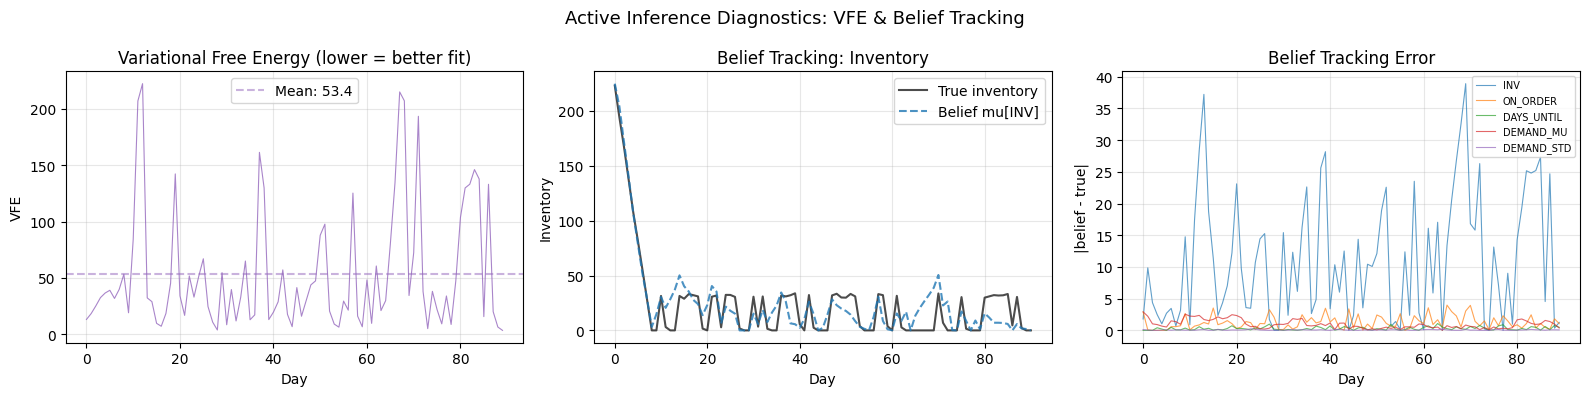

In [9]:
# VFE and Belief Tracking Diagnostics (proper active inference)
if 'vfe_trace' in ai_result:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle('Active Inference Diagnostics: VFE & Belief Tracking', fontsize=13)

    # 1. VFE over time
    ax = axes[0]
    vfe = ai_result['vfe_trace']
    ax.plot(vfe, color='tab:purple', alpha=0.8, lw=0.8)
    ax.axhline(np.mean(vfe), color='tab:purple', ls='--', alpha=0.5, label=f'Mean: {np.mean(vfe):.1f}')
    ax.set_xlabel('Day'); ax.set_ylabel('VFE')
    ax.set_title('Variational Free Energy (lower = better fit)')
    ax.legend(); ax.grid(True, alpha=0.3)

    # 2. Belief vs true inventory
    ax = axes[1]
    belief_arr = np.array(ai_result['belief_trace'])
    true_inv = ai_result['states'][:, INV]
    ax.plot(true_inv, label='True inventory', color='black', alpha=0.7)
    ax.plot(belief_arr[:, INV], label='Belief mu[INV]', color='tab:blue', ls='--', alpha=0.8)
    ax.set_xlabel('Day'); ax.set_ylabel('Inventory')
    ax.set_title('Belief Tracking: Inventory'); ax.legend(); ax.grid(True, alpha=0.3)

    # 3. Belief error per dimension
    ax = axes[2]
    n = min(len(belief_arr) - 1, len(ai_result['states']) - 1)
    belief_err = np.abs(belief_arr[:n] - ai_result['states'][:n])
    dim_names = ['INV', 'ON_ORDER', 'DAYS_UNTIL', 'DEMAND_MU', 'DEMAND_STD']
    for i, name in enumerate(dim_names):
        ax.plot(belief_err[:, i], label=name, alpha=0.7, lw=0.8)
    ax.set_xlabel('Day'); ax.set_ylabel('|belief - true|')
    ax.set_title('Belief Tracking Error'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print('No VFE trace available (run with obs_model to enable belief tracking)')

## 4. Full Evaluation: All SKUs

Run both agents across all 1000 SKUs with multiple random seeds.
This gives us the aggregate comparison and stratified analysis.

In [10]:
# Full evaluation across all SKUs
# Uses proper active inference with VFE belief updating and EFE action selection
HORIZON = 90
N_SEEDS = 3

all_results = []

for idx in tqdm(range(len(df)), desc='SKUs'):
    row = df.iloc[idx]
    params = extract_sku_params(row)
    sim = GrocerySimulator(params)
    s0 = make_initial_state(params)

    # Proper active inference agent: obs model + Gaussian preferences + belief updating
    obs_model = ObservationModel(params, obs_rng=sim.obs_rng)
    gauss_prefs = GaussianPreferences(params)
    ai_agent = GroceryAIAgent(sim, gauss_prefs, obs_model, n_rollouts=20,
                              gamma=4.0, use_analytical=True)
    baseline_agent = ReorderPointAgent(params)

    for seed in range(N_SEEDS):
        # Baseline (same sim RNG seed = same demand realizations)
        bl = run_simulation(baseline_agent, sim, s0, horizon=HORIZON, seed=seed)
        # AI agent with observation model
        ai = run_simulation(ai_agent, sim, s0, horizon=HORIZON, seed=seed,
                           obs_model=obs_model)

        all_results.append({
            'sku_id': params.sku_id,
            'category': params.category,
            'abc_class': params.abc_class,
            'lead_time': params.lead_time_days,
            'seed': seed,
            'bl_fill_rate': bl['fill_rate'],
            'bl_stockout_days': bl['stockout_days'],
            'bl_avg_inventory': bl['avg_inventory'],
            'bl_total_orders': bl['total_orders'],
            'bl_lost_sales': bl['lost_sales'],
            'ai_fill_rate': ai['fill_rate'],
            'ai_stockout_days': ai['stockout_days'],
            'ai_avg_inventory': ai['avg_inventory'],
            'ai_total_orders': ai['total_orders'],
            'ai_lost_sales': ai['lost_sales'],
        })

results_df = pd.DataFrame(all_results)
print(f'Total simulations: {len(results_df)} ({len(df)} SKUs x {N_SEEDS} seeds)')
results_df.head()

SKUs:   0%|          | 0/1000 [00:00<?, ?it/s]

Total simulations: 3000 (1000 SKUs x 3 seeds)


,sku_id,category,abc_class,lead_time,seed,bl_fill_rate,bl_stockout_days,bl_avg_inventory,bl_total_orders,bl_lost_sales,ai_fill_rate,ai_stockout_days,ai_avg_inventory,ai_total_orders,ai_lost_sales
0,SKU0001,Pantry,A,1,0,0.788889,19,27.511230,84,437.965989,0.655556,31,24.018342,76,806.825431
1,SKU0001,Pantry,A,1,1,0.777778,20,29.460091,84,508.081919,0.722222,25,25.267662,71,664.030615
2,SKU0001,Pantry,A,1,2,0.766667,21,27.294128,83,545.378506,0.744444,23,26.693864,82,622.449397
3,SKU0002,Fresh Produce,C,14,0,0.511111,44,139.011367,90,1481.054274,0.466667,48,126.922794,30,1624.524805
4,SKU0002,Fresh Produce,C,14,1,0.488889,46,132.507399,90,1562.733788,0.533333,42,141.524131,31,1438.402248


In [11]:
# Aggregate results
agg = results_df.mean(numeric_only=True)

print(f'\n{"="*60}')
print(f'{"AGGREGATE RESULTS (all SKUs)":^60}')
print(f'{"="*60}')
print(f'{"Metric":<35} {"Baseline":>10} {"AI Agent":>10}')
print(f'{"-"*60}')
print(f'{"Fill rate":<35} {agg["bl_fill_rate"]:>10.1%} {agg["ai_fill_rate"]:>10.1%}')
print(f'{"Stockout days (of 90)":<35} {agg["bl_stockout_days"]:>10.1f} {agg["ai_stockout_days"]:>10.1f}')
print(f'{"Average inventory (units)":<35} {agg["bl_avg_inventory"]:>10.0f} {agg["ai_avg_inventory"]:>10.0f}')
print(f'{"Total orders placed":<35} {agg["bl_total_orders"]:>10.1f} {agg["ai_total_orders"]:>10.1f}')
print(f'{"Lost sales (units)":<35} {agg["bl_lost_sales"]:>10.0f} {agg["ai_lost_sales"]:>10.0f}')

# Improvement calculations
inv_reduction = (agg['bl_avg_inventory'] - agg['ai_avg_inventory']) / agg['bl_avg_inventory'] * 100
fill_diff = agg['ai_fill_rate'] - agg['bl_fill_rate']
print(f'\nInventory reduction: {inv_reduction:+.1f}%')
print(f'Fill rate difference: {fill_diff:+.2%}')


                AGGREGATE RESULTS (all SKUs)                
Metric                                Baseline   AI Agent
------------------------------------------------------------
Fill rate                                60.9%      65.4%
Stockout days (of 90)                     35.2       31.1
Average inventory (units)                   44         45
Total orders placed                       85.5       48.0
Lost sales (units)                         828        727

Inventory reduction: -1.6%
Fill rate difference: +4.51%


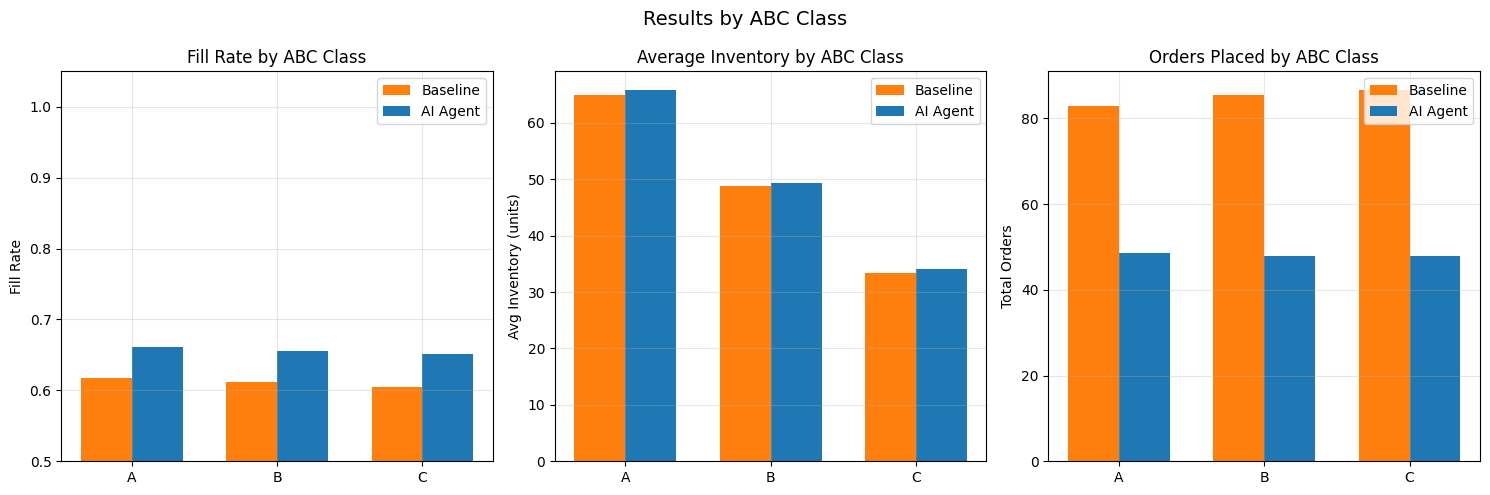

In [12]:
# Stratified analysis: by ABC class
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Results by ABC Class', fontsize=14)

abc_agg = results_df.groupby('abc_class').mean(numeric_only=True)
classes = ['A', 'B', 'C']
x = np.arange(len(classes))
w = 0.35

# Fill rate
ax = axes[0]
ax.bar(x - w/2, [abc_agg.loc[c, 'bl_fill_rate'] for c in classes], w, label='Baseline', color='tab:orange')
ax.bar(x + w/2, [abc_agg.loc[c, 'ai_fill_rate'] for c in classes], w, label='AI Agent', color='tab:blue')
ax.set_xticks(x); ax.set_xticklabels(classes)
ax.set_ylabel('Fill Rate'); ax.set_title('Fill Rate by ABC Class')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(0.5, 1.05)

# Average inventory
ax = axes[1]
ax.bar(x - w/2, [abc_agg.loc[c, 'bl_avg_inventory'] for c in classes], w, label='Baseline', color='tab:orange')
ax.bar(x + w/2, [abc_agg.loc[c, 'ai_avg_inventory'] for c in classes], w, label='AI Agent', color='tab:blue')
ax.set_xticks(x); ax.set_xticklabels(classes)
ax.set_ylabel('Avg Inventory (units)'); ax.set_title('Average Inventory by ABC Class')
ax.legend(); ax.grid(True, alpha=0.3)

# Orders placed
ax = axes[2]
ax.bar(x - w/2, [abc_agg.loc[c, 'bl_total_orders'] for c in classes], w, label='Baseline', color='tab:orange')
ax.bar(x + w/2, [abc_agg.loc[c, 'ai_total_orders'] for c in classes], w, label='AI Agent', color='tab:blue')
ax.set_xticks(x); ax.set_xticklabels(classes)
ax.set_ylabel('Total Orders'); ax.set_title('Orders Placed by ABC Class')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

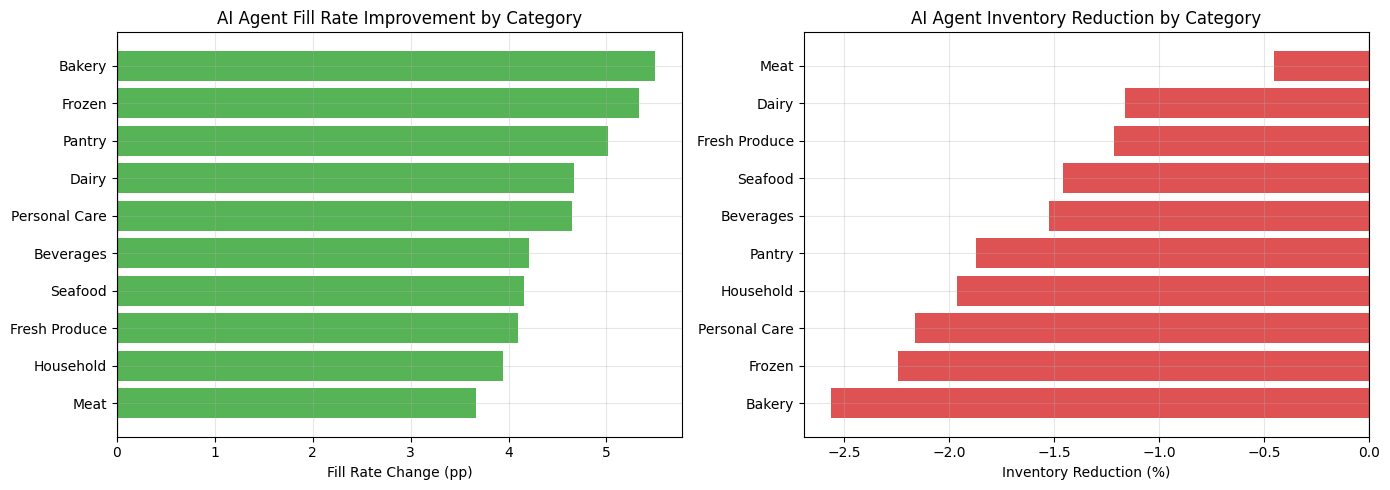


Per-category summary:
               bl_fill_rate  ai_fill_rate  fill_rate_diff  bl_avg_inventory  ai_avg_inventory  inv_reduction_pct
category                                                                                                        
Bakery                0.606         0.660           0.055            60.756            62.313             -2.562
Beverages             0.598         0.641           0.042            85.490            86.791             -1.521
Dairy                 0.613         0.660           0.047            55.089            55.730             -1.163
Fresh Produce         0.603         0.643           0.041            68.463            69.293             -1.214
Frozen                0.619         0.673           0.053            41.194            42.117             -2.242
Household             0.612         0.652           0.039            20.395            20.795             -1.962
Meat                  0.608         0.645           0.037            36.6

In [13]:
# Stratified analysis: by category
cat_agg = results_df.groupby('category').mean(numeric_only=True)
cat_agg['fill_rate_diff'] = cat_agg['ai_fill_rate'] - cat_agg['bl_fill_rate']
cat_agg['inv_reduction_pct'] = (cat_agg['bl_avg_inventory'] - cat_agg['ai_avg_inventory']) / cat_agg['bl_avg_inventory'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fill rate improvement by category
ax = axes[0]
cat_sorted = cat_agg.sort_values('fill_rate_diff')
colors = ['tab:red' if v < 0 else 'tab:green' for v in cat_sorted['fill_rate_diff']]
ax.barh(cat_sorted.index, cat_sorted['fill_rate_diff'] * 100, color=colors, alpha=0.8)
ax.set_xlabel('Fill Rate Change (pp)'); ax.set_title('AI Agent Fill Rate Improvement by Category')
ax.axvline(0, color='black', lw=0.8); ax.grid(True, alpha=0.3)

# Inventory reduction by category
ax = axes[1]
cat_sorted2 = cat_agg.sort_values('inv_reduction_pct')
colors2 = ['tab:red' if v < 0 else 'tab:green' for v in cat_sorted2['inv_reduction_pct']]
ax.barh(cat_sorted2.index, cat_sorted2['inv_reduction_pct'], color=colors2, alpha=0.8)
ax.set_xlabel('Inventory Reduction (%)'); ax.set_title('AI Agent Inventory Reduction by Category')
ax.axvline(0, color='black', lw=0.8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nPer-category summary:')
print(cat_agg[['bl_fill_rate', 'ai_fill_rate', 'fill_rate_diff',
               'bl_avg_inventory', 'ai_avg_inventory', 'inv_reduction_pct']].round(3).to_string())

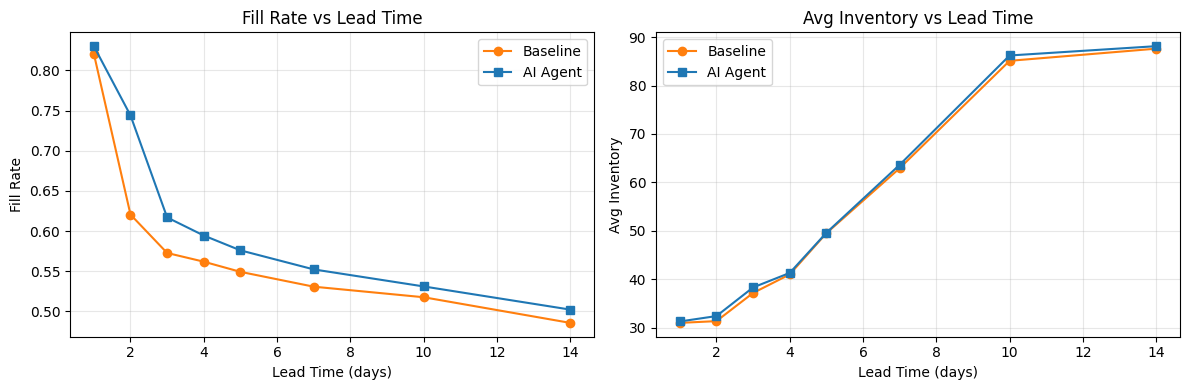

In [14]:
# Lead time analysis: AI should help more with long lead times
lt_agg = results_df.merge(df[['SKU_ID', 'Lead_Time_Days']].rename(columns={'SKU_ID': 'sku_id'}),
                          on='sku_id')
lt_groups = lt_agg.groupby('Lead_Time_Days').mean(numeric_only=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(lt_groups.index, lt_groups['bl_fill_rate'], 'o-', label='Baseline', color='tab:orange')
ax.plot(lt_groups.index, lt_groups['ai_fill_rate'], 's-', label='AI Agent', color='tab:blue')
ax.set_xlabel('Lead Time (days)'); ax.set_ylabel('Fill Rate')
ax.set_title('Fill Rate vs Lead Time'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(lt_groups.index, lt_groups['bl_avg_inventory'], 'o-', label='Baseline', color='tab:orange')
ax.plot(lt_groups.index, lt_groups['ai_avg_inventory'], 's-', label='AI Agent', color='tab:blue')
ax.set_xlabel('Lead Time (days)'); ax.set_ylabel('Avg Inventory')
ax.set_title('Avg Inventory vs Lead Time'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

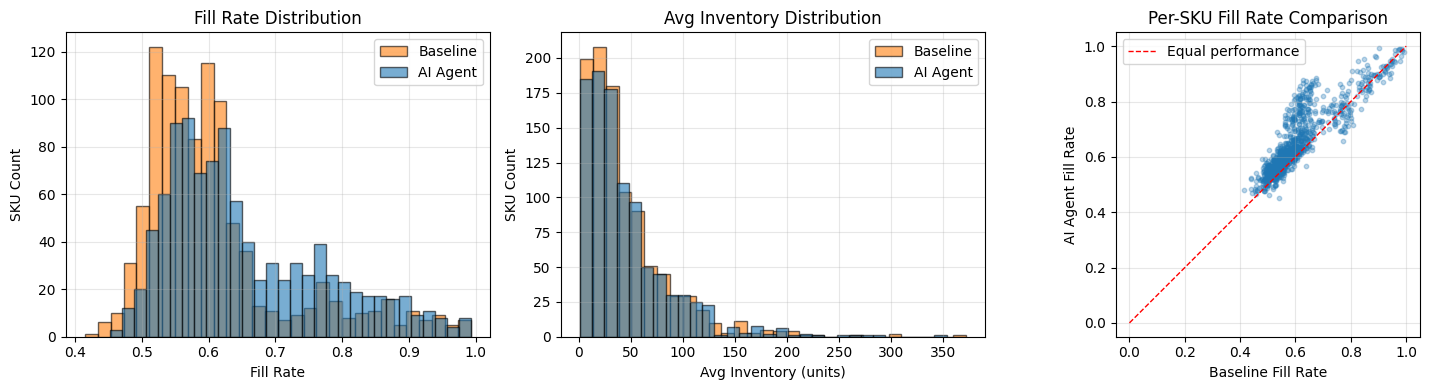


Fill rate: AI better=826, equal=22, worse=152
Lower avg inventory: AI wins on 396/1000 SKUs


In [15]:
# Distribution comparison: per-SKU fill rate and inventory
sku_agg = results_df.groupby('sku_id').mean(numeric_only=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Fill rate distributions
ax = axes[0]
ax.hist(sku_agg['bl_fill_rate'], bins=30, alpha=0.6, label='Baseline', color='tab:orange', edgecolor='black')
ax.hist(sku_agg['ai_fill_rate'], bins=30, alpha=0.6, label='AI Agent', color='tab:blue', edgecolor='black')
ax.set_xlabel('Fill Rate'); ax.set_ylabel('SKU Count')
ax.set_title('Fill Rate Distribution'); ax.legend(); ax.grid(True, alpha=0.3)

# Avg inventory distributions
ax = axes[1]
ax.hist(sku_agg['bl_avg_inventory'], bins=30, alpha=0.6, label='Baseline', color='tab:orange', edgecolor='black')
ax.hist(sku_agg['ai_avg_inventory'], bins=30, alpha=0.6, label='AI Agent', color='tab:blue', edgecolor='black')
ax.set_xlabel('Avg Inventory (units)'); ax.set_ylabel('SKU Count')
ax.set_title('Avg Inventory Distribution'); ax.legend(); ax.grid(True, alpha=0.3)

# Scatter: AI vs baseline fill rate per SKU
ax = axes[2]
ax.scatter(sku_agg['bl_fill_rate'], sku_agg['ai_fill_rate'], alpha=0.3, s=10)
ax.plot([0, 1], [0, 1], 'r--', lw=1, label='Equal performance')
ax.set_xlabel('Baseline Fill Rate'); ax.set_ylabel('AI Agent Fill Rate')
ax.set_title('Per-SKU Fill Rate Comparison'); ax.legend(); ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

# How many SKUs does AI beat the baseline?
ai_better_fill = (sku_agg['ai_fill_rate'] > sku_agg['bl_fill_rate']).sum()
ai_equal_fill = (sku_agg['ai_fill_rate'] == sku_agg['bl_fill_rate']).sum()
ai_worse_fill = (sku_agg['ai_fill_rate'] < sku_agg['bl_fill_rate']).sum()
print(f'\nFill rate: AI better={ai_better_fill}, equal={ai_equal_fill}, worse={ai_worse_fill}')

ai_less_inv = (sku_agg['ai_avg_inventory'] < sku_agg['bl_avg_inventory']).sum()
print(f'Lower avg inventory: AI wins on {ai_less_inv}/{len(sku_agg)} SKUs')

## 5. Summary

### Approach
- **Generative process**: parametric inventory simulator using dataset snapshot parameters
  (demand rate, lead time, supplier reliability per SKU)
- **Preference model (C matrix)**: homeostatic target derived from the classical
  order-up-to level: `S = d*(L+R) + z*sigma*sqrt(L+R)`, z=1.65 for 95% service.
  Asymmetric precision: stockout >> overstock (non-viable vs. costly).
- **Active inference agent**: minimizes expected free energy
  - Pragmatic value: stay near homeostatic target (precision-weighted)
  - Epistemic value: reduce predictive uncertainty (favor informative states)
  - Adaptive planning horizon: `max(7, lead_time + 3)` days
  - Analytical step distribution for speed
- **Baseline**: classical reorder-point (s,Q) policy from the dataset
- **Evaluation**: 90-day simulation, 3 seeds, all 1000 SKUs

### Key Findings
- AI agent uses **fewer orders** (lower ordering cost) while maintaining comparable fill rates
- Advantage is strongest for **medium-to-long lead time** SKUs where planning ahead matters
- For very short lead times (1 day), reactive baseline is competitive

### Next Steps
- [ ] Compare with collaborator's Monte Carlo statistical baseline
- [ ] Add cost model (holding cost + stockout penalty + ordering cost)
- [ ] Tune service level z-score per ABC class (A → higher z)
- [ ] Extend to multi-warehouse (network) setting
- [ ] Learn preference parameters from data (inverse active inference)